# Linear Regression for Interpretable Churn Prediction

**Assignment:** Assumption Junction, Individual Notebook (Model 1: Linear Regression)

**Goal:** Fit a linear probability model (OLS) to predict customer churn, check whether the linear regression assumptions hold, and judge whether this model is a responsible choice for explaining churn to the business.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM sample dataset), one row per customer with account, billing, and service features, plus a `Churn` label (`Yes`/`No`).


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Dataset Loading and Cleaning

Two known issues to fix on load:

- `TotalCharges` is text because 11 new customers (`tenure == 0`) have a blank value instead of a number. We convert it to numeric and fill those blanks with `0`.
- `customerID` has no predictive value, so we drop it.
- `Churn` is text (`Yes`/`No`); we encode it as `1`/`0` for regression.


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types and missing values before cleaning
print(df.dtypes)
print("\nMissing values (NaN) per column:", df.isnull().sum().sum())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values (NaN) per column: 0


In [4]:
# TotalCharges is object dtype because 11 rows hold a blank string instead of a number
blank_mask = df["TotalCharges"].str.strip() == ""
print(f"Rows with blank TotalCharges: {blank_mask.sum()}")
df.loc[blank_mask, ["tenure", "MonthlyCharges", "TotalCharges"]]

Rows with blank TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [5]:
# Clean TotalCharges: coerce to numeric, fill new-customer blanks with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop the identifier, encode the target
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"Clean shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.1%}")
df.dtypes

Clean shape: (7043, 20)
Churn rate: 26.5%


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

### Collapsing redundant service categories

Six columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) have a `"No internet service"` category that only exists because a customer with no internet can't have those add-ons either. `MultipleLines` has the same pattern with `"No phone service"`.

That category duplicates what `InternetService`/`PhoneService` already say, so we collapse it into `"No"` before encoding (this avoids a multicollinearity problem we'll hit below otherwise).

In [6]:
internet_dependent_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

for col in internet_dependent_cols:
    df[col] = df[col].replace("No internet service", "No")

df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

print(df["OnlineSecurity"].unique())
print(df["MultipleLines"].unique())

['No' 'Yes']
['No' 'Yes']


### One-hot encoding

Every remaining categorical column becomes 0/1 dummy columns via `pd.get_dummies`. We use `drop_first=True` to avoid the **dummy variable trap**: keeping every category would make the dummies for one variable always sum to 1, which is perfect collinearity by construction.

In [7]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# get_dummies returns bool columns, convert to int for cleaner stats/plots later
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Encoded shape: {df_encoded.shape}")
df_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoded shape: (7043, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## 3. Exploratory Data Analysis: Checking Linear Regression Assumptions

Six assumptions to check:

1. **Linearity**: predictors relate to the target roughly linearly.
2. **No multicollinearity**: predictors aren't near-duplicates of each other.
3. **Homoscedasticity**: residual variance is constant.
4. **Normality of residuals**: mostly matters for inference (p-values), not point predictions.
5. **Independence**: observations don't depend on each other.
6. **No influential outliers**: no single point dominates the fit.

Assumption 5 holds by design here (one row per customer, no time ordering), so the EDA below covers 1, 2, 3, 4, and 6.

### 3.1 Target class balance

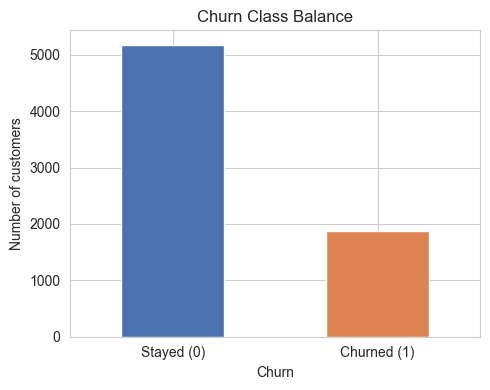

In [8]:
plt.figure(figsize=(5, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Stayed (0)", "Churned (1)"], rotation=0)
plt.ylabel("Number of customers")
plt.title("Churn Class Balance")
plt.tight_layout()
plt.show()

The target is binary, which is the first indication that linear regression (a model designed for continuous outcomes) is not a natural fit. In addition, only ~27% of observations are churn cases, indicating some class imbalance.

### 3.2 Linearity: numeric predictors vs. churn

/var/folders/jy/vk0rysr12_14_zxndg2t4n7h0000gn/T/ipykernel_43055/1165477559.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])
/var/folders/jy/vk0rysr12_14_zxndg2t4n7h0000gn/T/ipykernel_43055/1165477559.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])
/var/folders/jy/vk0rysr12_14_zxndg2t4n7h0000gn/T/ipykernel_43055/1165477559.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])


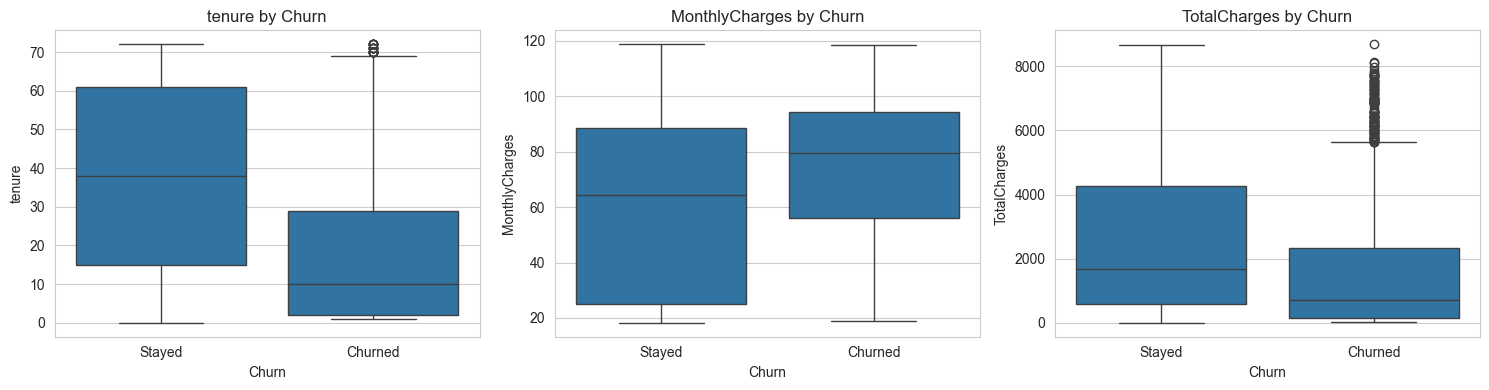

In [9]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_xticklabels(["Stayed", "Churned"])
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

`tenure` separates the two groups clearly and fairly monotonically, a good sign for linearity. `MonthlyCharges` and `TotalCharges` separate more weakly and noisily.

### 3.3 Multicollinearity: correlation, VIF, and a fix along the way

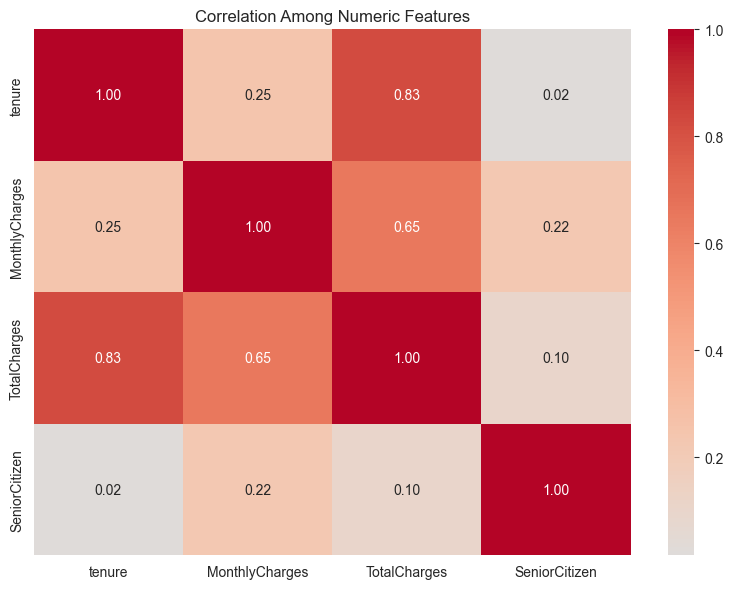

In [10]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols + ["SeniorCitizen"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Among Numeric Features")
plt.tight_layout()
plt.show()

`tenure` and `TotalCharges` correlate at ~0.83, which makes sense since `TotalCharges ≈ tenure x MonthlyCharges`. To check the full feature set (categoricals included), we compute the **Variance Inflation Factor (VIF)** for every column. VIF above roughly 5-10 signals redundant information.

In [11]:
X_check = df_encoded.drop(columns=["Churn"]).astype(float)
X_check_const = sm.add_constant(X_check)

vif_data = pd.DataFrame({
    "feature": X_check_const.columns,
    "VIF": [variance_inflation_factor(X_check_const.values, i) for i in range(X_check_const.shape[1])]
})
vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)
vif_data.head(10)

,feature,VIF
3,MonthlyCharges,865.062147
10,InternetService_Fiber optic,148.263380
11,InternetService_No,104.217482
8,PhoneService_Yes,34.861565
17,StreamingMovies_Yes,24.110253
16,StreamingTV_Yes,24.056827
4,TotalCharges,10.793729
2,tenure,7.527280
9,MultipleLines_Yes,7.273906
14,DeviceProtection_Yes,6.922434


A few features stand out. First, a sanity check: any VIF close to infinity? That would mean two columns carry identical information, worse than "just" a high VIF.

In [12]:
inf_features = vif_data[~np.isfinite(vif_data["VIF"])]
print(f"Features with infinite VIF: {len(inf_features)}")
inf_features

Features with infinite VIF: 0


,feature,VIF


Zero, which confirms the Section 2 fix worked: without collapsing `"No internet service"`/`"No phone service"`, columns like `InternetService_No` and `OnlineSecurity_No internet service` would be identical in every row, driving VIF to infinity.

In [13]:
assert inf_features.empty, "Still finding infinite VIF, the redundant categories were not fully collapsed."
print("No infinite VIF values.")

No infinite VIF values.


Two numeric features are still high, though: `MonthlyCharges` and `TotalCharges`. Different cause this time, no duplicated category. `MonthlyCharges` is basically a running total of which add-ons a customer pays for, so it duplicates information already in the service dummy columns. `TotalCharges` compounds that since it's roughly `tenure x MonthlyCharges`.

We drop both and keep `tenure` plus the individual service flags. Bonus: for a business that wants to act on this, "no tech support" is a more useful signal than an aggregate dollar amount anyway.

In [14]:
df_encoded = df_encoded.drop(columns=["MonthlyCharges", "TotalCharges"])
print(f"Shape after dropping the charge columns: {df_encoded.shape}")

Shape after dropping the charge columns: (7043, 22)


In [15]:
X_final_check = df_encoded.drop(columns=["Churn"]).astype(float)
X_final_check_const = sm.add_constant(X_final_check)

vif_final = pd.DataFrame({
    "feature": X_final_check_const.columns,
    "VIF": [variance_inflation_factor(X_final_check_const.values, i) for i in range(X_final_check_const.shape[1])]
})
vif_final = vif_final[vif_final["feature"] != "const"].sort_values("VIF", ascending=False)
vif_final.head(10)

,feature,VIF
2,tenure,2.785135
9,InternetService_No,2.698749
17,Contract_Two year,2.613895
8,InternetService_Fiber optic,2.006234
20,PaymentMethod_Electronic check,1.973799
21,PaymentMethod_Mailed check,1.841066
15,StreamingMovies_Yes,1.633899
14,StreamingTV_Yes,1.626085
16,Contract_One year,1.621942
19,PaymentMethod_Credit card (automatic),1.560358


Every VIF is now under 3. Multicollinearity is resolved.

## 4. Linear Regression Model (Linear Probability Model)

We fit OLS with `Churn` (0/1) as the target. Since the target is binary, this is technically a **Linear Probability Model (LPM)**: the output is read as an estimated churn probability, but nothing forces it to stay inside `[0, 1]`.

In [16]:
# Separate the features from the target variable
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Split the data into training and test sets, keeping the same churn proportion in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale the features using the training data
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the same scaling to the test data
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Train shape: (5634, 21), Test shape: (1409, 21)


In [17]:
# Create and train the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test = lr_model.predict(X_test_scaled)

print("Model fitted.")

Model fitted.


/Users/alberto/Library/CloudStorage/OneDrive-DukeUniversity/Duke/Academics/AIPI 590 XAI/31 aug task/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alberto/Library/CloudStorage/OneDrive-DukeUniversity/Duke/Academics/AIPI 590 XAI/31 aug task/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alberto/Library/CloudStorage/OneDrive-DukeUniversity/Duke/Academics/AIPI 590 XAI/31 aug task/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alberto/Library/CloudStorage/OneDrive-DukeUniversity/Duke/Academics/AIPI 590 XAI/31 aug task/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return

## 5. Model Performance Evidence

In [18]:
# Evaluate the model on the test set
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("Linear Regression (Linear Probability Model), test set")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

Linear Regression (Linear Probability Model), test set
MSE:  0.1437
RMSE: 0.3791
R2:   0.2630


R² and MSE show fit quality, but the real question is "did we flag the right customers?" We also threshold at 0.5 and report classification metrics for a more business-facing view.

Accuracy @ 0.5 threshold: 0.798


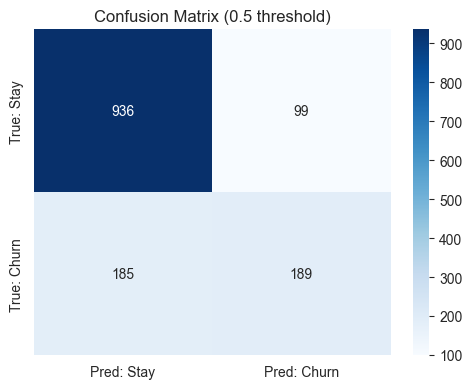

In [19]:
# Convert predictions into binary classes using a 0.5 threshold
y_pred_class = (y_pred_test >= 0.5).astype(int)

# Calculate classification accuracy
acc = accuracy_score(y_test, y_pred_class)
print(f"Accuracy @ 0.5 threshold: {acc:.3f}")

# Create and display the confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: Stay", "Pred: Churn"],
    yticklabels=["True: Stay", "True: Churn"]
)

plt.title("Confusion Matrix (0.5 threshold)")
plt.tight_layout()
plt.show()

In [20]:
# Check if any predictions fall outside the valid probability range [0, 1]
below_zero = (y_pred_test < 0).sum()
above_one = (y_pred_test > 1).sum()
total = len(y_pred_test)

print(f"Predictions below 0: {below_zero} ({below_zero/total:.1%})")
print(f"Predictions above 1: {above_one} ({above_one/total:.1%})")
print(f"Predicted value range: [{y_pred_test.min():.3f}, {y_pred_test.max():.3f}]")

Predictions below 0: 237 (16.8%)
Predictions above 1: 0 (0.0%)
Predicted value range: [-0.243, 0.787]


### Residual diagnostics

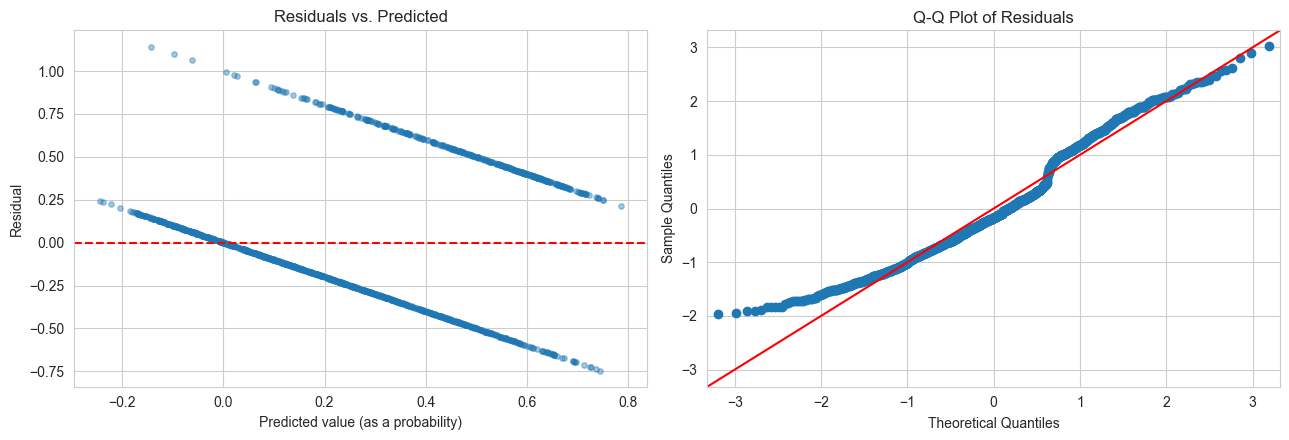

In [21]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred_test, residuals, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted value (as a probability)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs. Predicted")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

Two flags: the residual plot forms two diagonal bands instead of random scatter (a residual can only be `1 - prediction` or `0 - prediction` with a binary target, so this is expected, and it's evidence of heteroscedasticity). The Q-Q plot drifts off the 45-degree line at both ends, evidence against normality. Both are structural consequences of a 0/1 target, not something more features would fix.

We can confirm both formally.

In [22]:
X_train_const = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_const).fit()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(ols_model.resid, X_train_const)
print(f"Breusch-Pagan p-value: {bp_pvalue:.2e}")
print("Reject H0 (constant variance): heteroscedasticity is present" if bp_pvalue < 0.05
      else "Fail to reject H0: no strong evidence of heteroscedasticity")

Breusch-Pagan p-value: 6.83e-226
Reject H0 (constant variance): heteroscedasticity is present


In [23]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(ols_model.resid)
print(f"Jarque-Bera p-value: {jb_pvalue:.2e}")
print("Reject H0 (normal residuals): residuals are not normally distributed" if jb_pvalue < 0.05
      else "Fail to reject H0: no strong evidence against normality")

Jarque-Bera p-value: 2.68e-68
Reject H0 (normal residuals): residuals are not normally distributed


Both p-values are essentially zero: homoscedasticity and normality both fail. This mainly hurts the model's standard errors, p-values, and confidence intervals; the point predictions themselves are still usable.

### Influential observations: Cook's distance

Last check: is a handful of customers disproportionately steering the fit? Cook's Distance estimates how much the model would change if one observation were dropped. Screening threshold: `4/n`. Real concern starts around `1.0`.

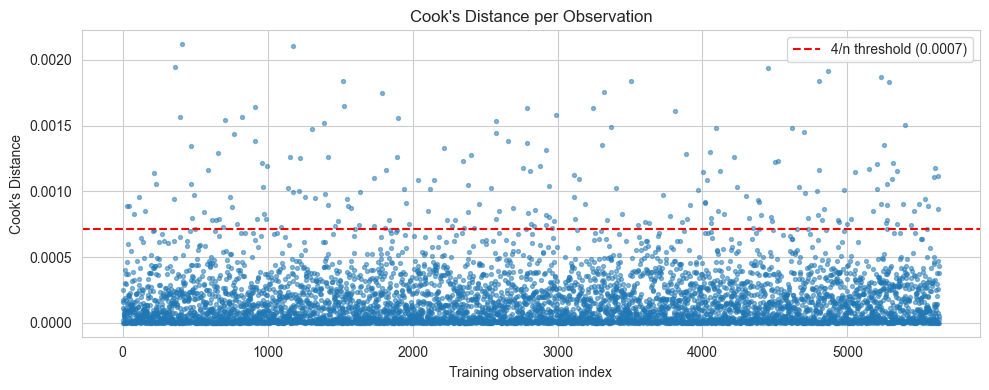

Observations above the 4/n threshold: 209 (3.7%)
Maximum Cook's Distance: 0.0021 (rule of thumb for concern: > 1.0)


In [24]:
influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(cooks_d)

plt.figure(figsize=(10, 4))
plt.scatter(range(len(cooks_d)), cooks_d, s=8, alpha=0.5)
plt.axhline(threshold, color="red", linestyle="--", label=f"4/n threshold ({threshold:.4f})")
plt.xlabel("Training observation index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance per Observation")
plt.legend()
plt.tight_layout()
plt.show()

n_flagged = (cooks_d > threshold).sum()
print(f"Observations above the 4/n threshold: {n_flagged} ({n_flagged/len(cooks_d):.1%})")
print(f"Maximum Cook's Distance: {cooks_d.max():.4f} (rule of thumb for concern: > 1.0)")

3.7% of customers sit above the strict `4/n` threshold, normal for a dataset this size. The max is 0.0021, far below the 1.0 concern threshold. No single customer dominates the fit.

## 6. Coefficient Interpretation

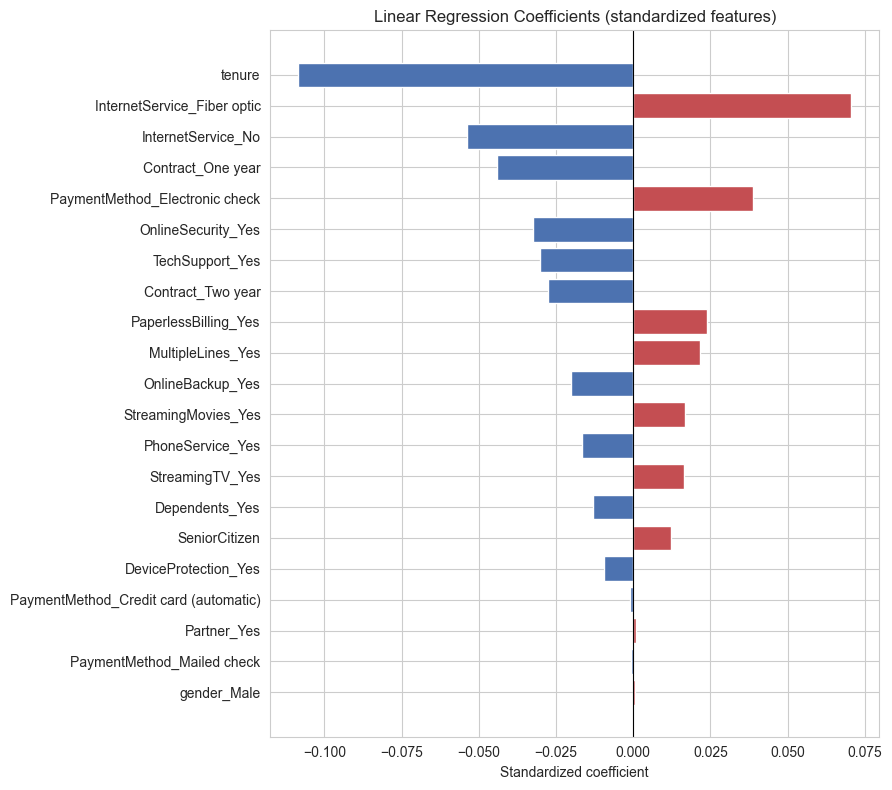

,feature,coefficient
1,tenure,-0.108560
7,InternetService_Fiber optic,0.070670
8,InternetService_No,-0.053806
15,Contract_One year,-0.044175
19,PaymentMethod_Electronic check,0.038873
9,OnlineSecurity_Yes,-0.032426
12,TechSupport_Yes,-0.030188
16,Contract_Two year,-0.027657
17,PaperlessBilling_Yes,0.024060
6,MultipleLines_Yes,0.021507


In [25]:
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

plt.figure(figsize=(9, 8))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in coef_df["coefficient"]]
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Standardized coefficient")
plt.title("Linear Regression Coefficients (standardized features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coef_df.head(10)

Features were standardized, so each coefficient is roughly the change in predicted churn probability (percentage points) per standard-deviation increase, holding everything else fixed (for a dummy, per switch from the baseline category). Red raises churn, blue lowers it.

Top effects:

- **`tenure`** (largest, negative): more time with the company, lower predicted churn. Matches the EDA.
- **`InternetService_Fiber optic`** (positive, vs. DSL baseline): fiber customers churn more, even controlling for contract and add-ons. Worth flagging as a possible service or pricing issue.
- **`InternetService_No`** (negative): phone-only customers churn less than DSL customers.
- **`Contract_One year` / `Contract_Two year`** (both negative): any fixed-term contract lowers churn vs. month-to-month.
- **`OnlineSecurity_Yes` / `TechSupport_Yes`** (both negative): these add-ons associate with lower churn, a possible retention lever.
- **`PaymentMethod_Electronic check`** (positive): churns more than automatic payment methods, maybe a proxy for lower engagement.

The appeal of the LPM: these coefficients read directly in probability points, easier for a non-technical audience than logistic regression's log-odds.

## 7. Limitations of Linear Regression for Churn

1. **Predictions aren't proper probabilities.** ~17% of test predictions fall below 0 (down to about -24%). These raw outputs are not valid probabilities and are unsuitable as calibrated risk scores.
2. **Heteroscedasticity**, confirmed by Breusch-Pagan, is expected with a binary target and limits the reliability of standard OLS inference, particularly conventional standard errors and p-values (robust standard errors could partially address this).
3. **Non-normal residuals** (confirmed by Jarque-Bera) are also expected here and further weaken the statistical inference, though not the point predictions.
4. **No curvature near the boundary.** Logistic regression flattens out near 0 and 1; the LPM's straight line keeps extrapolating, which can give unrealistic predictions at the extremes.

The LPM's coefficients are easy to explain to a non-technical audience: a one-unit increase in X raises churn probability by Y points. But given the issues above, it's better treated as a descriptive tool than a source of calibrated probabilities or rigorous inference. For production risk scoring, a model built for binary outcomes, like logistic regression, is the safer choice.